# ΚΑΡΑΝΑΣΙΟΣ ΑΘΑΝΑΣΙΟΣ ΑΓΓΕΛΟΣ
# ΑΕΜ:15919
**ΑΠΑΝΤΗΣΕΙΣ ΤΟΥ 2ου ΣΕΤ ΑΞΙΟΛΟΓΗΣΗΣ(ΠΚΦ)**

***ΕΡΩΤΗΣΗ 1***

Οι μονες προσθηκες ητανε α)η αντικατασταση των στοιχειων των πινακων Pauli β) οι συνιστωσες του μαγνητικου πεδιου και γ)μια απλη εντολη για το εσωτερικο γινομενο:

In [2]:
%matplotlib ipympl
import matplotlib
import matplotlib.pyplot as plt 
from matplotlib.widgets import Slider, Button, RadioButtons
import numpy as np
import numpy.linalg
import math

B=3    #  
alpha = 1./137   # Σταθερά λεπτής υφής
g = 2*(1+alpha/(2*numpy.pi)) # γυρομαγνητικός λόγος
hbar = 1   # Η σταθερά του Planck

def pauli_matrices():    
    sig_x = numpy.matrix([ [0,1], [1,0] ])# Αλλάξτε εδώ
    sig_y = numpy.matrix([ [0,-1j], [1j,0] ])# Αλλάξτε εδώ
    sig_z = numpy.matrix([ [1,0], [0,-1] ])# Αλλάξτε εδώ
    
    sigmas = numpy.array([sig_x, sig_y, sig_z])
    return sigmas

def magnetic_field(theta, B):
    return numpy.array([0, 3*np.sin(theta), 3*np.cos(theta)])  # Αλλάξτε εδώ

def Hamiltonian(theta, B):
    sigmas = pauli_matrices()
    B_vector = magnetic_field(theta, B)
    H = -g*0.5*hbar*np.tensordot(B_vector,sigmas,axes=1)#Κατασκευάστε την Χαμιλτονιανή, Δέστε την Scipy συνάρτηση "tensordot" για να πάρετε το εσ. γινόμενο μεταξύ B και sigmas
    return H

theta_check = numpy.pi / 4
print("H= ",Hamiltonian(theta_check,B))


H=  [[-2.12378471+0.j          0.        +2.12378471j]
 [-0.        -2.12378471j  2.12378471-0.j        ]]


***Ερωτηση 2***
Σε αυτη την ερωτηση προσθεσα μονο τη μεταβλητη Psi_dagger: 

In [16]:
H = Hamiltonian(numpy.pi/3, B)
print("H=",H)
(energies, eigenstates) =np.linalg.eigh(H)#Χρησιμοποιήστε την συνάρτηση numpy.linalg.eigh 
Psi_dagger=eigenstates.conj().T
print("E=",energies,energies.shape)
print("Psi*=\n",Psi_dagger,Psi_dagger.shape)
print("Psi=\n",eigenstates,eigenstates.shape)
print("Psi.conj.T*Psi=\n",np.dot(eigenstates,Psi_dagger)) #Ελέγξτε Psi^\dagger\Psi=I; δείτε numpy.dot 

H= [[-1.50174257+0.j          0.        +2.60109444j]
 [-0.        -2.60109444j  1.50174257-0.j        ]]
E= [-3.00348514  3.00348514] (2,)
Psi*=
 [[-0.8660254+0.j         0.       +0.5j      ]
 [-0.5      -0.j         0.       -0.8660254j]] (2, 2)
Psi=
 [[-0.8660254-0.j        -0.5      +0.j       ]
 [ 0.       -0.5j        0.       +0.8660254j]] (2, 2)
Psi.conj.T*Psi=
 [[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]


***Ερωτηση 3***: χρησιμοποιησα το @ για το γινομενο αντι του np.dot() επειδη το αποτελεσμα δεν ητανε σωστο ειτε χρησιμοποιουσα np.dot(np.dot(A,B),C) ή np.dot(A,np.dot(B,C))

In [17]:
print(Psi_dagger@H@eigenstates,"\nΑρα ειναι πραγματι διαγωνιος και ισος με Ε") # Εκτυπώστε το διαγώνιο πίνακα

[[-3.00348514+0.j  0.        +0.j]
 [ 0.        +0.j  3.00348514+0.j]] 
Αρα ειναι πραγματι διαγωνιος και ισος με Ε


***Ερωτηση 4***: Απο τη θεωρια,απλως συμπληρωσα τον κωδικα για το $$ \chi(0)_B = \Psi^\dagger \chi(0)_z$$

In [19]:
H = Hamiltonian(numpy.pi/5, B)
(energies, eigenstates) = numpy.linalg.eigh(H)
psi_0_zbasis = numpy.matrix([[1],[0]])
psi_0_Bbasis =np.dot(eigenstates.conj().T,psi_0_zbasis) #ποια είναι η \chi(0)_B?
print("chi(0)_z=\n",psi_0_zbasis)
print("chi(0)_B=\n",psi_0_Bbasis)


chi(0)_z=
 [[1]
 [0]]
chi(0)_B=
 [[-0.95105652+0.j]
 [-0.30901699+0.j]]


***Ερωτηση 5***: Στο for loop αντικαθιστω απλως τα στοιχεια των πινακων για το $ \chi(t)_B $

In [20]:
H = Hamiltonian(numpy.pi/3, B)
(energies, eigenstates) = numpy.linalg.eigh(H)
psi_0_zbasis = numpy.matrix([[1],[0]])
psi_0_Bbasis =np.dot(eigenstates.conj().T,psi_0_zbasis) # ϊδιος κώδικας με πάνω

def get_psi_t_Bbasis(energies, psi_0_Bbasis, time):
    psi_t_Bbasis = numpy.matrix(numpy.zeros_like(psi_0_Bbasis))
    for i in range(0, len(energies)):
        psi_t_Bbasis[i,0] = psi_0_Bbasis[i,0]*np.exp((-1j/hbar)*energies[i]*time)#Ποιο είναι το \chi(t)_B?
    return psi_t_Bbasis

print(H)
print("chi(t=5)_B=\n",get_psi_t_Bbasis(energies, psi_0_Bbasis, 5))

[[-1.50174257+0.j          0.        +2.60109444j]
 [-0.        -2.60109444j  1.50174257-0.j        ]]
chi(t=5)_B=
 [[0.66762222-0.55161633j]
 [0.38545187+0.31847583j]]



***Ερωτηση 6***: Ουσιαστικα στο overlap πρεπει να γραφει το bra $<\chi(0)_B|$ που ειναι το $|\chi(0)_B>^{\dagger}$ και το ket $|\chi(t)_B>$


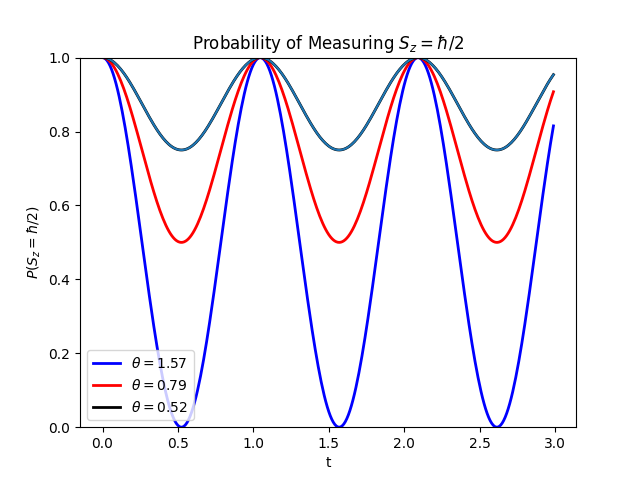

In [21]:
t = numpy.arange(0,3,0.01)
thetas = [numpy.pi/2, numpy.pi/4, numpy.pi/6]
colors = ['blue','red','black']

plt.figure()
for k in range(0, len(thetas)):
    theta = thetas[k]
    (energies, eigenstates) = numpy.linalg.eigh( Hamiltonian(theta, B) )
    prob_sz_up = numpy.zeros_like(t)
    psi_0_zbasis = numpy.matrix([[1],[0]])
    psi_0_Bbasis = numpy.dot( eigenstates.conj().T, psi_0_zbasis )
    for i in range(0, len(t)):
        psi_t_Bbasis = get_psi_t_Bbasis(energies, psi_0_Bbasis, t[i])
        overlap = numpy.dot(psi_0_Bbasis.conj().T, psi_t_Bbasis)[0,0]           # Συμπλη΄ρωστε τα κενά
        prob_sz_up[i] = (numpy.conjugate(overlap)*overlap).real # Συμπληρώστε τα κενά
    plt.plot(t, prob_sz_up, color=colors[k], lw=2, label=r'$\theta=$'+str("%.2f" %theta))
    

plt.plot(t, prob_sz_up)
plt.xlabel("t")
plt.ylabel(r"$P(S_z=\hbar/2)$")
plt.title(r"Probability of Measuring $S_z=\hbar/2$")
plt.legend()
plt.ylim([0,1])
plt.savefig("ProbSzUp_Solution.png")
plt.show()